In [22]:
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

In [23]:
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

DATA_PATH = r"C:/Programming/ETH/SS26/ISQT26/final/playground/market_data.xlsx"
SHEET_NAME = "US"
LEGEND_SHEET_NAME = "legend"
TARGET = "_MKT"

SEED = 122
TEST_YEARS = 5
HORIZON = 1
VOL_WINDOW = 8
K_LAGS = 8
PAST_VOL_WINDOWS = (4, 8, 13, 26, 52)
VAL_FRAC = 0.2
EPS = 1e-8

CELL = "GRU"
HIDDEN_SIZE = 8
NUM_LAYERS = 1
DROPOUT = 0.0

LR = 1e-3
WEIGHT_DECAY = 1e-3
EPOCHS = 1000
PATIENCE = 100
CLIP_GRAD = 1.0
SHOW_PROGRESS = True

LOSS_TYPE = "asymmetric_mse"
UNDER_WEIGHT = 2.5
HIGH_VOL_ALPHA = 2.0

USE_CALIBRATION = True
CALIBRATION_MIN_STD = 1e-8

SIGNAL_CHANGE_WINDOW = 8
SIGNAL_THRESHOLD_MODE = "quantile"
SIGNAL_THRESHOLD_VALUE = 1
SIGNAL_THRESHOLD_QUANTILE = 0.85
INITIAL_SHARES = 1.0
MAX_SHARES = 1.0
TRANSACTION_COST_BPS = 0.0

set_seed(SEED)

In [24]:
df = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME, engine="openpyxl", index_col=0)
namings = pd.read_excel(DATA_PATH, sheet_name=LEGEND_SHEET_NAME, engine="openpyxl", index_col=0)

df.index = pd.to_datetime(df.index)
df = df.sort_index()

In [25]:
def build_vol_dataset(df, target, horizon, window, past_vol_windows, eps):
    X = df.drop(columns=[target])
    Y = df[target]

    def safe_log(s):
        return np.log(s.where(s > 0))

    def dlog(s):
        return np.log(s / s.shift(horizon))

    def fisher(s):
        rho = s.clip(-1 + eps, 1 - eps)
        return np.arctanh(rho)

    def logit_prob(s):
        p = (s / 100).clip(eps, 1 - eps)
        return np.log(p / (1 - p))

    Z = pd.DataFrame(index=df.index)

    Z["EMP"]  = X["EMP"]
    Z["PE"]   = safe_log(X["PE"])
    Z["CAPE"] = safe_log(X["CAPE"])
    Z["DY"]   = safe_log(X["DY"])
    Z["Rho"]  = fisher(X["Rho"])
    Z["MOV "] = safe_log(X["MOV "])

    Z["IR"]   = X["IR"]
    Z["RR"]   = X["RR"]
    Z["Y02"]  = X["Y02"]
    Z["Y10"]  = X["Y10"]
    Z["STP"]  = X["STP"]

    Z["CF"]   = X["CF"]
    Z["MG"]   = X["MG"]
    Z["RV"]   = X["RV"]
    Z["ED"]   = X["ED"]
    Z["UN"]   = X["UN"]
    Z["GDP"]  = X["GDP"]
    Z["M2"]   = X["M2"]
    Z["CPI"]  = X["CPI"]
    Z["DIL"]  = X["DIL"]

    Z["YSS"]  = np.log1p(X["YSS"])
    Z["NYF"]  = logit_prob(X["NYF"])

    Z["_AU"]  = dlog(X["_AU"])
    Z["_DXY"] = dlog(X["_DXY"])
    Z["_LCP"] = dlog(X["_LCP"])
    Z["_TY"]  = dlog(X["_TY"])
    Z["_OIL"] = dlog(X["_OIL"])

    Z["_VA"]  = dlog(X["_VA"])
    Z["_GR"]  = dlog(X["_GR"])

    mkt_ret = np.log(Y / Y.shift(1))

    Z["_MKT_ret_1"] = mkt_ret
    Z["_MKT_absret_1"] = mkt_ret.abs()

    for w in past_vol_windows:
        Z[f"_MKT_vol_{w}"] = mkt_ret.rolling(w).std(ddof=0)

    Z["_MKT_ewm_vol_13"] = mkt_ret.ewm(span=13, adjust=False).std(bias=True)
    Z["_MKT_ewm_vol_26"] = mkt_ret.ewm(span=26, adjust=False).std(bias=True)

    y_sigma = pd.Series(index=df.index, dtype=float)
    y_end_date = pd.Series(index=df.index, dtype="datetime64[ns]")

    for t in range(len(df)):
        start = t + horizon
        end = start + window

        if end <= len(df):
            rr = mkt_ret.iloc[start:end]
            if rr.notna().all():
                y_sigma.iloc[t] = rr.std(ddof=0)
                y_end_date.iloc[t] = df.index[end - 1]

    data = pd.concat(
        [
            Z,
            y_sigma.rename("y_sigma"),
            y_end_date.rename("y_end_date"),
        ],
        axis=1,
    )

    return data.replace([np.inf, -np.inf], np.nan).dropna()

In [26]:
def split_and_standardize(data, test_years, val_frac):
    split_date = data.index.max() - pd.DateOffset(years=test_years)

    train = data.loc[data["y_end_date"] < split_date].copy()
    test = data.loc[data.index >= split_date].copy()

    feature_cols = [c for c in data.columns if c not in ["y_sigma", "y_end_date"]]

    X_train_raw = train[feature_cols]
    X_test_raw = test[feature_cols]

    y_train_raw = train["y_sigma"]
    y_test_raw = test["y_sigma"]

    y_std = y_train_raw.std(ddof=0)

    params = {
        "X_mean": X_train_raw.mean(),
        "X_std": X_train_raw.std(ddof=0).replace(0, 1),
        "Y_mean": y_train_raw.mean(),
        "Y_std": y_std if y_std != 0 else 1,
    }

    X_train = (X_train_raw - params["X_mean"]) / params["X_std"]
    X_test = (X_test_raw - params["X_mean"]) / params["X_std"]

    y_train = (y_train_raw - params["Y_mean"]) / params["Y_std"]
    y_test = (y_test_raw - params["Y_mean"]) / params["Y_std"]

    return X_train, X_test, y_train, y_test, y_train_raw, y_test_raw, params, feature_cols, split_date

In [27]:
def make_rnn_windows(X, y, k):
    data = pd.concat([X, y.rename("target")], axis=1).replace([np.inf, -np.inf], np.nan).dropna()

    X_values = data.drop(columns=["target"]).to_numpy(dtype=np.float32)
    y_values = data["target"].to_numpy(dtype=np.float32)

    X_seq = []
    y_seq = []
    idx = []

    for end in range(k - 1, len(data)):
        start = end - k + 1
        X_seq.append(X_values[start:end + 1])
        y_seq.append(y_values[end])
        idx.append(data.index[end])

    X_seq = torch.tensor(np.asarray(X_seq), dtype=torch.float32)
    y_seq = torch.tensor(np.asarray(y_seq).reshape(-1, 1), dtype=torch.float32)

    return X_seq, y_seq, pd.DatetimeIndex(idx)

In [28]:
vol_data = build_vol_dataset(
    df=df,
    target=TARGET,
    horizon=HORIZON,
    window=VOL_WINDOW,
    past_vol_windows=PAST_VOL_WINDOWS,
    eps=EPS,
)

X_train, X_test, Y_train, Y_test, Y_train_sigma, Y_test_sigma, params, feature_cols, split_date = split_and_standardize(
    data=vol_data,
    test_years=TEST_YEARS,
    val_frac=VAL_FRAC,
)

X_train_rnn, Y_train_rnn, train_idx = make_rnn_windows(X_train, Y_train, K_LAGS)
X_test_rnn, Y_test_rnn, test_idx = make_rnn_windows(X_test, Y_test, K_LAGS)

val_start = int(len(X_train_rnn) * (1 - VAL_FRAC))

X_tr_rnn = X_train_rnn[:val_start]
Y_tr_rnn = Y_train_rnn[:val_start]

X_val_rnn = X_train_rnn[val_start:]
Y_val_rnn = Y_train_rnn[val_start:]

train_fit_idx = train_idx[:val_start]
val_idx = train_idx[val_start:]

n_features = X_train_rnn.shape[2]

pd.Series({
    "features": n_features,
    "train_sequences": len(X_tr_rnn),
    "validation_sequences": len(X_val_rnn),
    "test_sequences": len(X_test_rnn),
    "split_date": split_date,
})

features                                 38
train_sequences                        1320
validation_sequences                    331
test_sequences                          254
split_date              2021-03-08 00:00:00
dtype: object

In [29]:
class VolRNN(torch.nn.Module):
    def __init__(self, n_features, hidden_size, num_layers, dropout, cell, seed):
        super().__init__()
        set_seed(seed)

        self.cell = cell.upper()

        if self.cell == "RNN":
            self.rnn = torch.nn.RNN(
                input_size=n_features,
                hidden_size=hidden_size,
                num_layers=num_layers,
                dropout=dropout if num_layers > 1 else 0.0,
                batch_first=True,
                nonlinearity="tanh",
            )
        elif self.cell == "LSTM":
            self.rnn = torch.nn.LSTM(
                input_size=n_features,
                hidden_size=hidden_size,
                num_layers=num_layers,
                dropout=dropout if num_layers > 1 else 0.0,
                batch_first=True,
            )
        else:
            self.rnn = torch.nn.GRU(
                input_size=n_features,
                hidden_size=hidden_size,
                num_layers=num_layers,
                dropout=dropout if num_layers > 1 else 0.0,
                batch_first=True,
            )

        self.head = torch.nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out[:, -1, :])

In [30]:
def tensor_metrics(y_true, y_pred):
    with torch.no_grad():
        err = y_pred - y_true
        rmse = torch.sqrt(torch.mean(err ** 2)).item()
        mae = torch.mean(torch.abs(err)).item()
        hit = (torch.sign(y_pred) == torch.sign(y_true)).float().mean().item()

    return {
        "hit": hit,
        "rmse": rmse,
        "mae": mae,
    }


def numpy_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    err = y_pred - y_true
    return {
        "hit": np.mean(np.sign(y_pred) == np.sign(y_true)),
        "rmse": np.sqrt(np.mean(err ** 2)),
        "mae": np.mean(np.abs(err)),
    }


def evaluate_model(model, X, y):
    model.eval()
    with torch.no_grad():
        pred = model(X)
    return tensor_metrics(y, pred)


def predict_model(model, X):
    model.eval()
    with torch.no_grad():
        return model(X).detach().cpu().numpy().ravel()


def rnn_loss(pred, target, loss_type, under_weight, high_vol_alpha):
    err = pred - target

    if loss_type == "asymmetric_mse":
        weight = torch.where(err < 0, under_weight, 1.0)
        return (weight * err ** 2).mean()

    if loss_type == "high_vol_weighted_mse":
        weight = 1.0 + high_vol_alpha * torch.relu(target)
        return (weight * err ** 2).mean()

    return torch.mean(err ** 2)

In [31]:
def train_rnn(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    lr,
    weight_decay,
    epochs,
    patience,
    clip_grad,
    loss_type,
    under_weight,
    high_vol_alpha,
    show_progress,
):
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    hist = {
        "train_hit": [],
        "val_hit": [],
        "train_rmse": [],
        "val_rmse": [],
        "train_mae": [],
        "val_mae": [],
    }

    best_state = None
    best_val = np.inf
    wait = 0

    iterator = tqdm(range(epochs), desc="Training") if show_progress else range(epochs)

    for _ in iterator:
        model.train()
        opt.zero_grad()

        pred_train = model(X_train)
        loss = rnn_loss(pred_train, y_train, loss_type, under_weight, high_vol_alpha)
        loss.backward()

        if clip_grad is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)

        opt.step()

        model.eval()
        with torch.no_grad():
            pred_train = model(X_train)
            pred_val = model(X_val)
            val_loss = rnn_loss(pred_val, y_val, loss_type, under_weight, high_vol_alpha).item()

        train_m = tensor_metrics(y_train, pred_train)
        val_m = tensor_metrics(y_val, pred_val)

        hist["train_hit"].append(train_m["hit"])
        hist["val_hit"].append(val_m["hit"])
        hist["train_rmse"].append(train_m["rmse"])
        hist["val_rmse"].append(val_m["rmse"])
        hist["train_mae"].append(train_m["mae"])
        hist["val_mae"].append(val_m["mae"])

        if val_loss < best_val - 1e-8:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if show_progress:
            iterator.set_postfix({
                "train_hit": f"{train_m['hit']:.3f}",
                "val_hit": f"{val_m['hit']:.3f}",
                "train_rmse": f"{train_m['rmse']:.3f}",
                "val_rmse": f"{val_m['rmse']:.3f}",
            })

        if patience is not None and wait >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    hist["model"] = model
    hist["best_val_loss"] = best_val
    hist["epochs_run"] = len(hist["val_rmse"])

    return hist

In [32]:
model = VolRNN(
    n_features=n_features,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    cell=CELL,
    seed=SEED,
)

hist = train_rnn(
    model=model,
    X_train=X_tr_rnn,
    y_train=Y_tr_rnn,
    X_val=X_val_rnn,
    y_val=Y_val_rnn,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    epochs=EPOCHS,
    patience=PATIENCE,
    clip_grad=CLIP_GRAD,
    loss_type=LOSS_TYPE,
    under_weight=UNDER_WEIGHT,
    high_vol_alpha=HIGH_VOL_ALPHA,
    show_progress=SHOW_PROGRESS,
)

pd.Series({
    "epochs_run": hist["epochs_run"],
    "best_val_loss": hist["best_val_loss"],
})

Training:   0%|          | 0/1000 [00:00<?, ?it/s]

epochs_run       207.000000
best_val_loss      2.914912
dtype: float64

In [33]:
train_pred_raw = predict_model(model, X_tr_rnn)
val_pred_raw = predict_model(model, X_val_rnn)
test_pred_raw = predict_model(model, X_test_rnn)

train_actual = Y_tr_rnn.detach().cpu().numpy().ravel()
val_actual = Y_val_rnn.detach().cpu().numpy().ravel()
test_actual = Y_test_rnn.detach().cpu().numpy().ravel()

if USE_CALIBRATION:
    x = val_pred_raw
    y = val_actual
    x_std = np.std(x)
    if x_std > CALIBRATION_MIN_STD:
        cal_b, cal_a = np.polyfit(x, y, 1)
    else:
        cal_b = 0.0
        cal_a = np.mean(y)
else:
    cal_a = 0.0
    cal_b = 1.0

train_pred = cal_a + cal_b * train_pred_raw
val_pred = cal_a + cal_b * val_pred_raw
test_pred = cal_a + cal_b * test_pred_raw

metrics = pd.DataFrame(
    {
        "train_raw": numpy_metrics(train_actual, train_pred_raw),
        "validation_raw": numpy_metrics(val_actual, val_pred_raw),
        "test_raw": numpy_metrics(test_actual, test_pred_raw),
        "train": numpy_metrics(train_actual, train_pred),
        "validation": numpy_metrics(val_actual, val_pred),
        "test": numpy_metrics(test_actual, test_pred),
    }
).T

calibration = pd.Series({"calibration_intercept": cal_a, "calibration_slope": cal_b})

display(calibration)
metrics

calibration_intercept    0.11987
calibration_slope        0.85700
dtype: float64

,hit,rmse,mae
train_raw,0.716667,0.753882,0.547543
validation_raw,0.734139,1.132699,0.669358
test_raw,0.649606,0.687024,0.526834
train,0.672727,0.784888,0.584051
validation,0.719033,1.120515,0.702481
test,0.590551,0.692595,0.546879


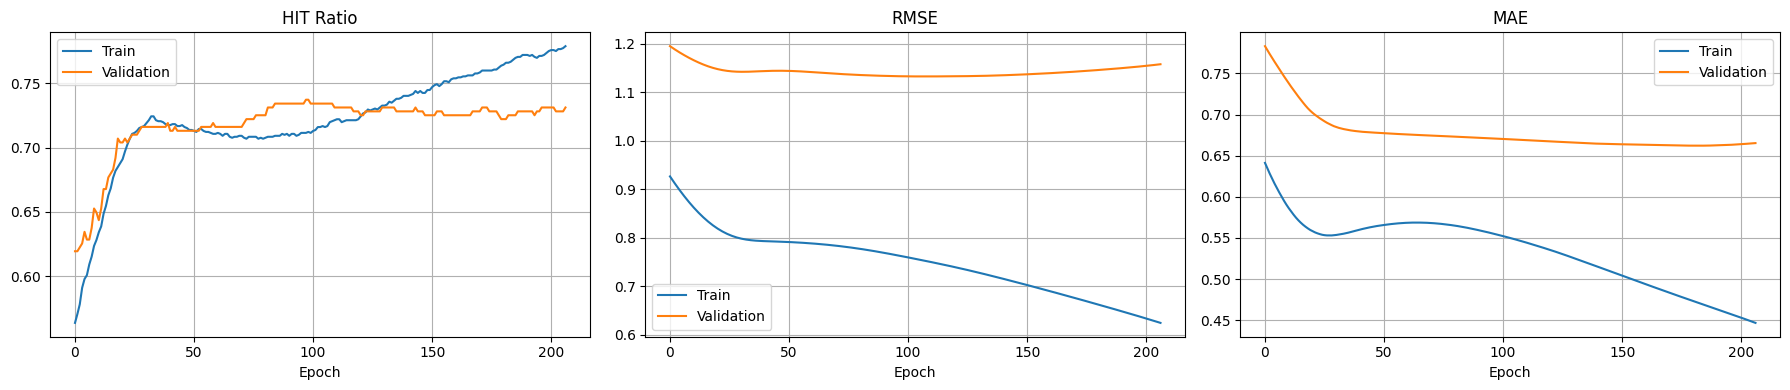

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(hist["train_hit"], label="Train")
axes[0].plot(hist["val_hit"], label="Validation")
axes[0].set_title("HIT Ratio")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(hist["train_rmse"], label="Train")
axes[1].plot(hist["val_rmse"], label="Validation")
axes[1].set_title("RMSE")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(hist["train_mae"], label="Train")
axes[2].plot(hist["val_mae"], label="Validation")
axes[2].set_title("MAE")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [35]:
pred = pd.DataFrame(
    {
        "actual_vol_z": test_actual,
        "predicted_vol_z_raw": test_pred_raw,
        "predicted_vol_z": test_pred,
    },
    index=test_idx,
)

val_pred = pd.DataFrame(
    {
        "actual_vol_z": val_actual,
        "predicted_vol_z_raw": val_pred_raw,
        "predicted_vol_z": val_pred,
    },
    index=val_idx,
)

pred.tail()

,actual_vol_z,predicted_vol_z_raw,predicted_vol_z
2026-02-08,-0.065051,-0.355725,-0.184986
2026-02-15,0.287005,-0.200549,-0.052001
2026-02-22,0.705443,-0.327066,-0.160425
2026-03-01,0.690782,-0.333465,-0.165909
2026-03-08,0.519856,0.241377,0.326731


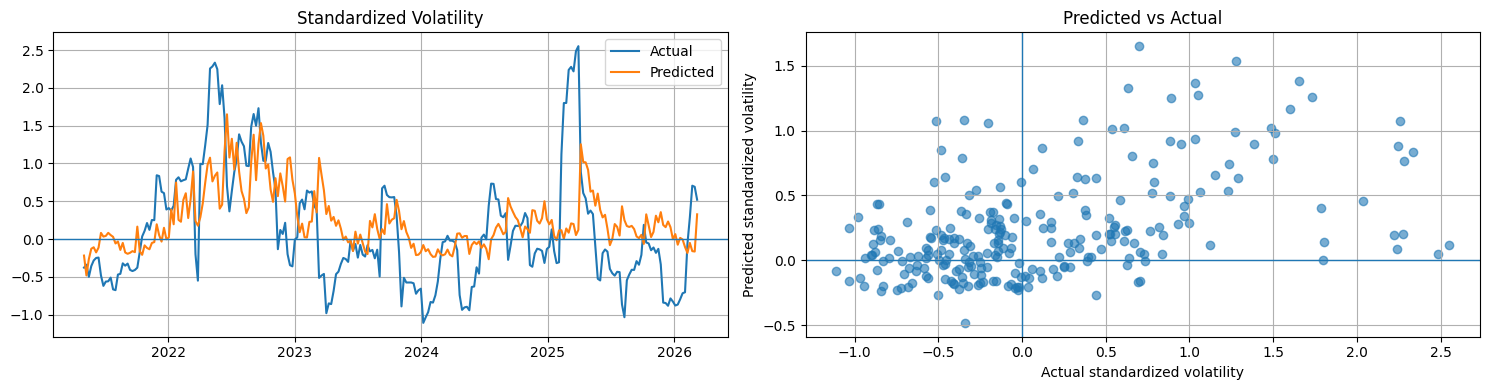

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].plot(pred.index, pred["actual_vol_z"], label="Actual")
axes[0].plot(pred.index, pred["predicted_vol_z"], label="Predicted")
axes[0].axhline(0.0, linewidth=1)
axes[0].set_title("Standardized Volatility")
axes[0].legend()
axes[0].grid(True)

axes[1].scatter(pred["actual_vol_z"], pred["predicted_vol_z"], alpha=0.6)
axes[1].axhline(0.0, linewidth=1)
axes[1].axvline(0.0, linewidth=1)
axes[1].set_xlabel("Actual standardized volatility")
axes[1].set_ylabel("Predicted standardized volatility")
axes[1].set_title("Predicted vs Actual")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [37]:
def resolve_signal_threshold(val_pred, signal_change_window, mode, value, quantile):
    val_change = val_pred["predicted_vol_z"].diff(signal_change_window)

    if mode == "quantile":
        threshold = np.nanquantile(np.abs(val_change), quantile)
        if not np.isfinite(threshold) or threshold <= 0:
            threshold = value
        return threshold

    return value


SIGNAL_THRESHOLD = resolve_signal_threshold(
    val_pred=val_pred,
    signal_change_window=SIGNAL_CHANGE_WINDOW,
    mode=SIGNAL_THRESHOLD_MODE,
    value=SIGNAL_THRESHOLD_VALUE,
    quantile=SIGNAL_THRESHOLD_QUANTILE,
)

pd.Series({
    "signal_change_window": SIGNAL_CHANGE_WINDOW,
    "signal_threshold": SIGNAL_THRESHOLD,
    "signal_threshold_mode": SIGNAL_THRESHOLD_MODE,
})

signal_change_window            8
signal_threshold         0.553755
signal_threshold_mode    quantile
dtype: object

In [38]:
def run_self_financing_vol_strategy(
    pred,
    df,
    target,
    signal_change_window,
    threshold,
    initial_shares,
    max_shares,
    transaction_cost_bps,
):
    bt = pred.copy()
    bt["MKT"] = df[target].reindex(bt.index)
    bt = bt.dropna().copy()

    bt["predicted_vol_change_z"] = bt["predicted_vol_z"].diff(signal_change_window)
    bt["actual_vol_change_z"] = bt["actual_vol_z"].diff(signal_change_window)
    bt["mkt_return"] = bt["MKT"].pct_change()
    bt["mkt_diff"] = bt["MKT"].diff()

    initial_price = bt["MKT"].iloc[0]
    initial_wealth = initial_price
    shares = min(initial_shares, max_shares, initial_wealth / initial_price)
    cash = initial_wealth - shares * initial_price
    cost_rate = transaction_cost_bps / 10000

    strategy_value = []
    cash_path = []
    shares_path = []
    signal_path = []
    trade_path = []

    for i, (_, row) in enumerate(bt.iterrows()):
        price = row["MKT"]

        if i == 0:
            strategy_value.append(cash + shares * price)
            cash_path.append(cash)
            shares_path.append(shares)
            signal_path.append(0.0)
            trade_path.append(0.0)
            continue

        x = row["predicted_vol_change_z"]
        desired_shares = shares
        signal = 0.0

        if pd.notna(x):
            if x >= threshold:
                desired_shares = 0.0
                signal = -1.0
            elif x <= -threshold:
                desired_shares = max_shares
                signal = 1.0

        trade = 0.0

        if desired_shares < shares:
            sell_qty = shares - desired_shares
            proceeds = sell_qty * price
            cost = proceeds * cost_rate
            cash += proceeds - cost
            shares -= sell_qty
            trade = -sell_qty

        elif desired_shares > shares:
            buy_qty = min(desired_shares - shares, max(cash, 0.0) / (price * (1 + cost_rate)), max_shares - shares)
            cost = buy_qty * price * cost_rate
            cash -= buy_qty * price + cost
            shares += buy_qty
            trade = buy_qty

        strategy_value.append(cash + shares * price)
        cash_path.append(cash)
        shares_path.append(shares)
        signal_path.append(signal)
        trade_path.append(trade)

    bt["cash"] = cash_path
    bt["shares"] = shares_path
    bt["signal"] = signal_path
    bt["trade"] = trade_path
    bt["strategy_value"] = strategy_value
    bt["baseline_value"] = bt["MKT"]
    bt["active_value"] = bt["strategy_value"] - bt["baseline_value"]
    bt["strategy_return"] = bt["strategy_value"] / bt["strategy_value"].iloc[0] - 1.0
    bt["baseline_return"] = bt["baseline_value"] / bt["baseline_value"].iloc[0] - 1.0
    bt["active_return"] = bt["strategy_return"] - bt["baseline_return"]

    strategy_pnl = bt["strategy_value"].diff().dropna()
    baseline_pnl = bt["baseline_value"].diff().dropna()
    active_pnl = strategy_pnl - baseline_pnl
    active_sr = active_pnl.mean() / active_pnl.std() * np.sqrt(52) if active_pnl.std() > 0 else np.nan

    pred_sell = bt["predicted_vol_change_z"] >= threshold
    pred_buy = bt["predicted_vol_change_z"] <= -threshold
    pred_trigger = pred_sell | pred_buy
    actual_sell = bt["actual_vol_change_z"] >= threshold
    actual_buy = bt["actual_vol_change_z"] <= -threshold
    actual_trigger = actual_sell | actual_buy
    same_direction_trigger = (pred_sell & actual_sell) | (pred_buy & actual_buy)

    diagnostics = {
        "corr_mkt_return_predicted_vol_z": bt["mkt_return"].corr(bt["predicted_vol_z"]),
        "corr_mkt_return_predicted_vol_change_z": bt["mkt_return"].corr(bt["predicted_vol_change_z"]),
        "corr_mkt_return_actual_vol_z": bt["mkt_return"].corr(bt["actual_vol_z"]),
        "corr_mkt_return_actual_vol_change_z": bt["mkt_return"].corr(bt["actual_vol_change_z"]),
    }

    metrics = pd.Series({
        "final_strategy_value": bt["strategy_value"].iloc[-1],
        "final_baseline_value": bt["baseline_value"].iloc[-1],
        "final_active_value": bt["active_value"].iloc[-1],
        "strategy_return": bt["strategy_return"].iloc[-1],
        "baseline_return": bt["baseline_return"].iloc[-1],
        "active_return": bt["active_return"].iloc[-1],
        "active_sr": active_sr,
        "mean_shares": bt["shares"].mean(),
        "time_in_market": (bt["shares"] > 0).mean(),
        "number_of_trades": (bt["trade"].abs() > 0).sum(),
        "total_turnover_units": bt["trade"].abs().sum(),
        "predicted_trigger_count": pred_trigger.sum(),
        "actual_trigger_count": actual_trigger.sum(),
        "same_direction_trigger_count": same_direction_trigger.sum(),
        "missed_actual_triggers": (actual_trigger & ~pred_trigger).sum(),
        "false_predicted_triggers": (pred_trigger & ~actual_trigger).sum(),
        "threshold": threshold,
        "signal_change_window": signal_change_window,
        **diagnostics,
    })

    return bt, metrics

In [39]:
strategy_bt, strategy_metrics = run_self_financing_vol_strategy(
    pred=pred,
    df=df,
    target=TARGET,
    signal_change_window=SIGNAL_CHANGE_WINDOW,
    threshold=SIGNAL_THRESHOLD,
    initial_shares=INITIAL_SHARES,
    max_shares=MAX_SHARES,
    transaction_cost_bps=TRANSACTION_COST_BPS,
)

strategy_metrics

final_strategy_value                      20696.199304
final_baseline_value                      27023.670000
final_active_value                        -6327.470696
strategy_return                               0.263263
baseline_return                               0.649482
active_return                                -0.386219
active_sr                                    -0.573805
mean_shares                                   0.592022
time_in_market                                0.657480
number_of_trades                             11.000000
total_turnover_units                          9.331508
predicted_trigger_count                      42.000000
actual_trigger_count                        121.000000
same_direction_trigger_count                 14.000000
missed_actual_triggers                       94.000000
false_predicted_triggers                     15.000000
threshold                                     0.553755
signal_change_window                          8.000000
corr_mkt_r

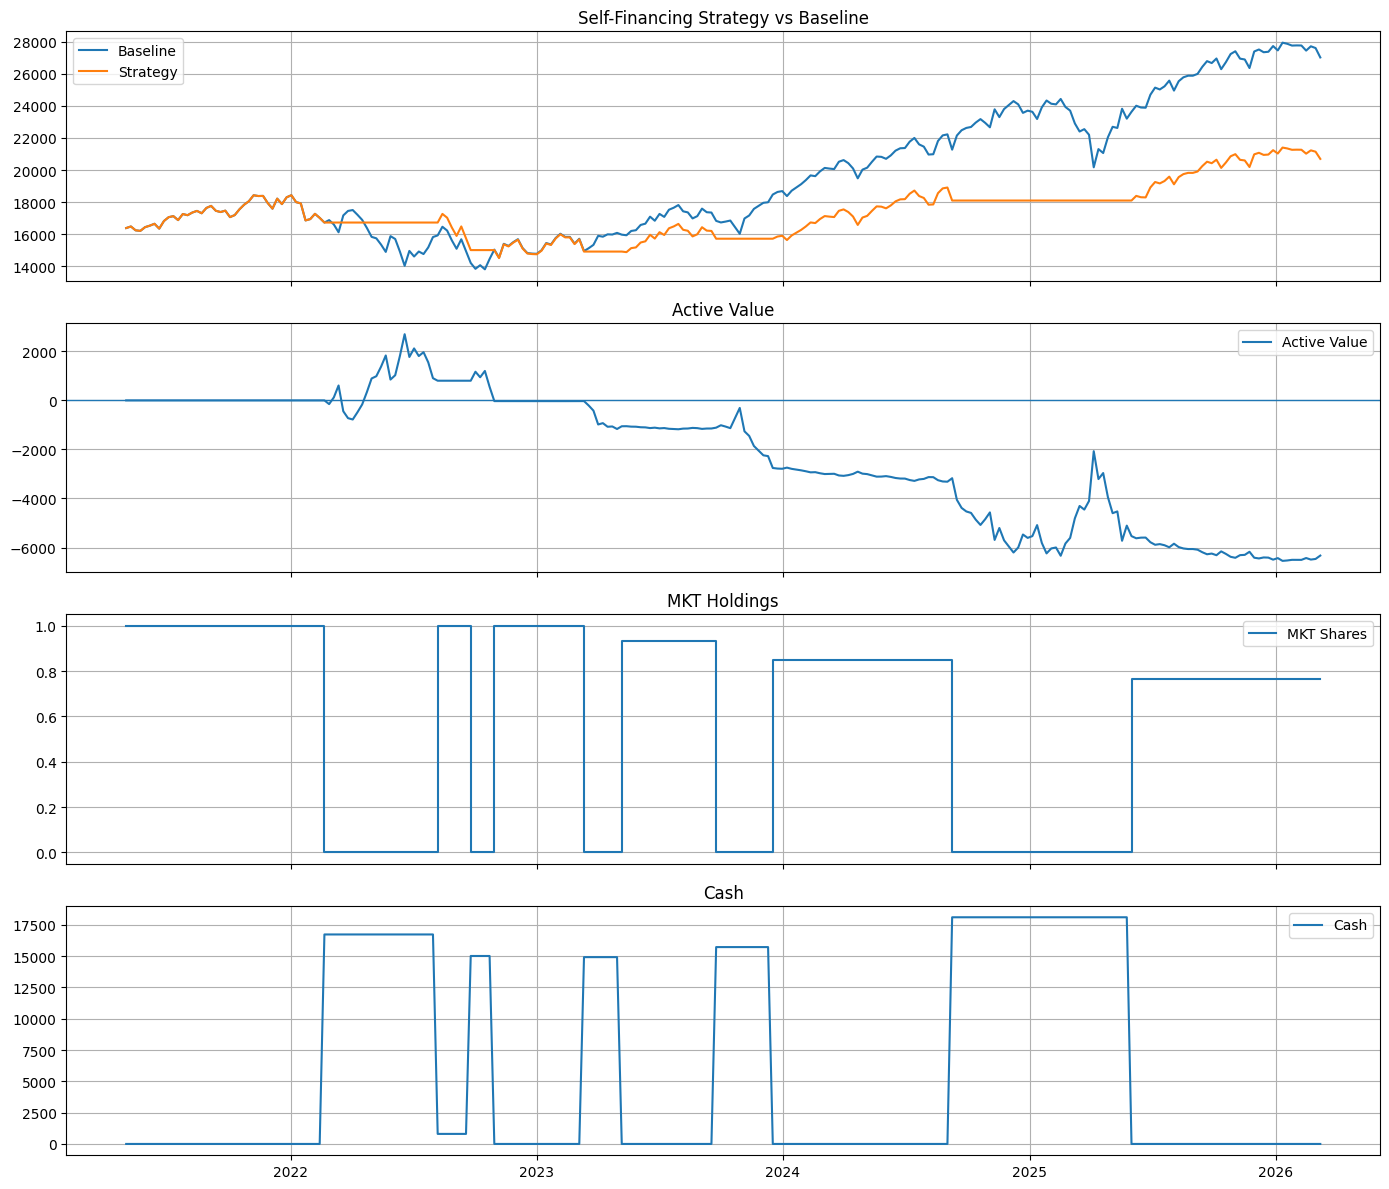

In [40]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(strategy_bt.index, strategy_bt["baseline_value"], label="Baseline")
axes[0].plot(strategy_bt.index, strategy_bt["strategy_value"], label="Strategy")
axes[0].set_title("Self-Financing Strategy vs Baseline")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(strategy_bt.index, strategy_bt["active_value"], label="Active Value")
axes[1].axhline(0.0, linewidth=1)
axes[1].set_title("Active Value")
axes[1].legend()
axes[1].grid(True)

axes[2].step(strategy_bt.index, strategy_bt["shares"], where="post", label="MKT Shares")
axes[2].set_ylim(-0.05, MAX_SHARES + 0.05)
axes[2].set_title("MKT Holdings")
axes[2].legend()
axes[2].grid(True)

axes[3].plot(strategy_bt.index, strategy_bt["cash"], label="Cash")
axes[3].set_title("Cash")
axes[3].legend()
axes[3].grid(True)

plt.tight_layout()
plt.show()

predicted_trigger_count          42
actual_trigger_count            121
same_direction_trigger_count     14
predicted_sell_count             20
predicted_buy_count              22
actual_sell_count                56
actual_buy_count                 65
missed_actual_triggers           94
false_predicted_triggers         15
dtype: int64

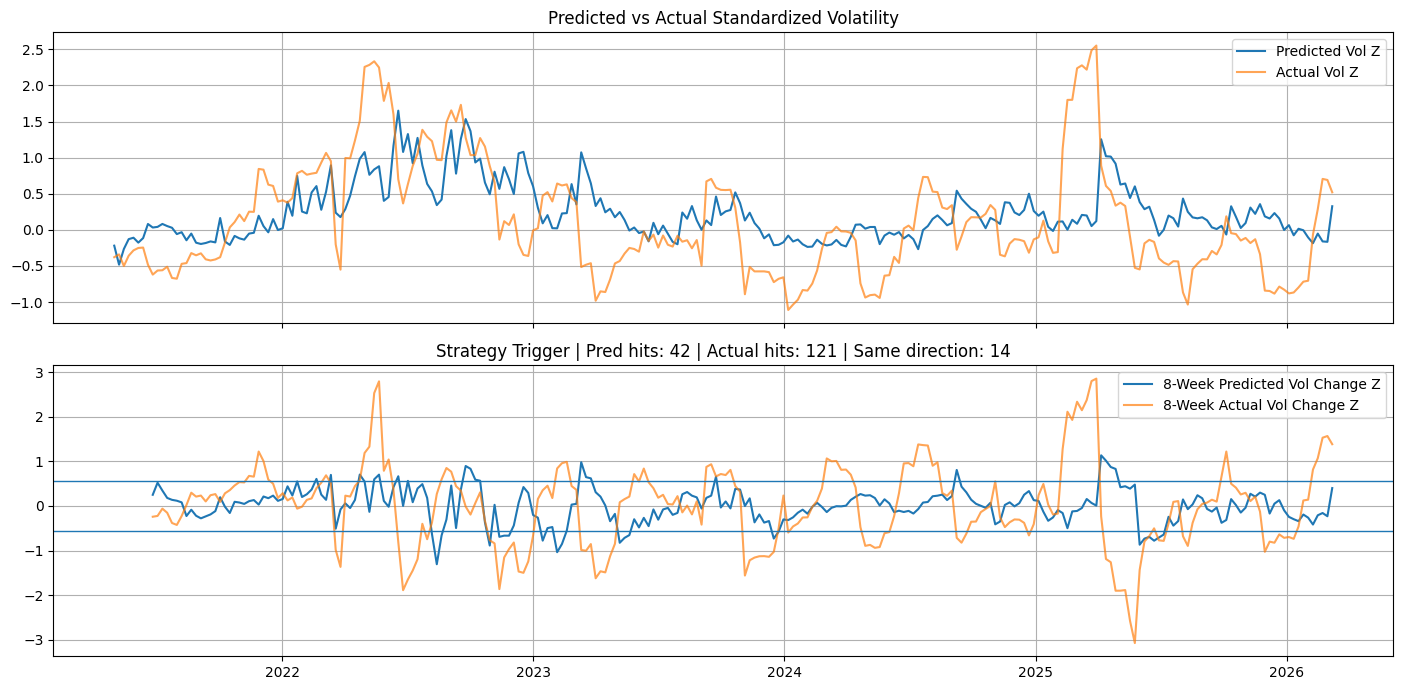

In [41]:
pred_sell = strategy_bt["predicted_vol_change_z"] >= SIGNAL_THRESHOLD
pred_buy = strategy_bt["predicted_vol_change_z"] <= -SIGNAL_THRESHOLD
pred_trigger = pred_sell | pred_buy

actual_sell = strategy_bt["actual_vol_change_z"] >= SIGNAL_THRESHOLD
actual_buy = strategy_bt["actual_vol_change_z"] <= -SIGNAL_THRESHOLD
actual_trigger = actual_sell | actual_buy

same_direction_trigger = (pred_sell & actual_sell) | (pred_buy & actual_buy)

hit_stats = pd.Series({
    "predicted_trigger_count": pred_trigger.sum(),
    "actual_trigger_count": actual_trigger.sum(),
    "same_direction_trigger_count": same_direction_trigger.sum(),
    "predicted_sell_count": pred_sell.sum(),
    "predicted_buy_count": pred_buy.sum(),
    "actual_sell_count": actual_sell.sum(),
    "actual_buy_count": actual_buy.sum(),
    "missed_actual_triggers": (actual_trigger & ~pred_trigger).sum(),
    "false_predicted_triggers": (pred_trigger & ~actual_trigger).sum(),
})

display(hit_stats)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(strategy_bt.index, strategy_bt["predicted_vol_z"], label="Predicted Vol Z")
axes[0].plot(strategy_bt.index, strategy_bt["actual_vol_z"], label="Actual Vol Z", alpha=0.7)
axes[0].set_title("Predicted vs Actual Standardized Volatility")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(strategy_bt.index, strategy_bt["predicted_vol_change_z"], label=f"{SIGNAL_CHANGE_WINDOW}-Week Predicted Vol Change Z")
axes[1].plot(strategy_bt.index, strategy_bt["actual_vol_change_z"], label=f"{SIGNAL_CHANGE_WINDOW}-Week Actual Vol Change Z", alpha=0.7)
axes[1].axhline(SIGNAL_THRESHOLD, linewidth=1)
axes[1].axhline(-SIGNAL_THRESHOLD, linewidth=1)
axes[1].set_title(f"Strategy Trigger | Pred hits: {pred_trigger.sum()} | Actual hits: {actual_trigger.sum()} | Same direction: {same_direction_trigger.sum()}")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [42]:
strategy_bt[
    [
        "MKT",
        "actual_vol_z",
        "predicted_vol_z",
        "predicted_vol_change_z",
        "actual_vol_change_z",
        "shares",
        "cash",
        "strategy_value",
        "baseline_value",
        "active_value",
    ]
].tail(20)

,MKT,actual_vol_z,predicted_vol_z,predicted_vol_change_z,actual_vol_change_z,shares,cash,strategy_value,baseline_value,active_value
2025-10-26,27236.44,-0.148569,0.025786,-0.148015,0.258770,0.765855,0.0,20859.150166,27236.44,-6377.289834
2025-11-02,27409.11,-0.112643,0.094043,-0.038088,0.296367,0.765855,0.0,20991.390263,27409.11,-6417.719737
2025-11-09,26948.06,-0.183139,0.308547,0.274215,0.109820,0.765855,0.0,20638.293045,26948.06,-6309.766955
2025-11-16,26897.68,-0.130395,0.221283,0.210436,0.210165,0.765855,0.0,20599.709296,26897.68,-6297.970704
2025-11-23,26362.62,-0.337199,0.355751,0.300520,-0.126746,0.765855,0.0,20189.931186,26362.62,-6172.688814
2025-11-30,27395.12,-0.841951,0.186002,0.251127,-1.029193,0.765855,0.0,20980.675959,27395.12,-6414.444041
2025-12-07,27520.29,-0.847368,0.156669,-0.169587,-0.800961,0.765855,0.0,21076.537967,27520.29,-6443.752033
2025-12-14,27348.96,-0.883686,0.231736,0.051940,-0.825120,0.765855,0.0,20945.324115,27348.96,-6403.635885
2025-12-21,27377.70,-0.786384,0.156759,0.130973,-0.637815,0.765855,0.0,20967.334773,27377.70,-6410.365227
2025-12-28,27733.44,-0.828049,-0.002431,-0.096474,-0.715405,0.765855,0.0,21239.779854,27733.44,-6493.660146


In [43]:
ORACLE_SIGNAL_COL = "actual_vol_z"

def run_known_vol_strategy(
    pred,
    df,
    target="_MKT",
    signal_col="actual_vol_z",
    signal_change_window=8,
    threshold=0.75,
    max_shares=1.0,
):
    bt = pred.copy()
    bt["MKT"] = df[target].reindex(bt.index)
    bt = bt.dropna().copy()

    bt["known_vol_change_z"] = bt[signal_col].diff(signal_change_window)

    cash = 0.0
    shares = max_shares

    strategy_value = []
    cash_path = []
    shares_path = []
    signal_path = []

    for i, (_, row) in enumerate(bt.iterrows()):
        price = row["MKT"]

        if i == 0:
            value = cash + shares * price
            strategy_value.append(value)
            cash_path.append(cash)
            shares_path.append(shares)
            signal_path.append(0.0)
            continue

        x = row["known_vol_change_z"]
        desired_shares = shares
        signal = 0.0

        if pd.notna(x):
            if x >= threshold:
                desired_shares = 0.0
                signal = -1.0
            elif x <= -threshold:
                desired_shares = max_shares
                signal = 1.0

        if desired_shares < shares:
            sell_qty = shares - desired_shares
            cash += sell_qty * price
            shares -= sell_qty

        elif desired_shares > shares:
            buy_qty = min(desired_shares - shares, cash / price, max_shares - shares)
            cash -= buy_qty * price
            shares += buy_qty

        value = cash + shares * price

        strategy_value.append(value)
        cash_path.append(cash)
        shares_path.append(shares)
        signal_path.append(signal)

    bt["cash"] = cash_path
    bt["shares"] = shares_path
    bt["signal"] = signal_path
    bt["strategy_value"] = strategy_value

    bt["baseline_value"] = bt["MKT"] * max_shares
    bt["active_value"] = bt["strategy_value"] - bt["baseline_value"]

    bt["strategy_return"] = bt["strategy_value"] / bt["strategy_value"].iloc[0] - 1.0
    bt["baseline_return"] = bt["baseline_value"] / bt["baseline_value"].iloc[0] - 1.0
    bt["active_return"] = bt["strategy_return"] - bt["baseline_return"]

    strategy_pnl = bt["strategy_value"].diff().dropna()
    baseline_pnl = bt["baseline_value"].diff().dropna()
    active_pnl = strategy_pnl - baseline_pnl

    active_sr = active_pnl.mean() / active_pnl.std() * np.sqrt(52) if active_pnl.std() > 0 else np.nan
    trades = bt["shares"].diff().abs().fillna(0.0)

    metrics = pd.Series({
        "final_strategy_value": bt["strategy_value"].iloc[-1],
        "final_baseline_value": bt["baseline_value"].iloc[-1],
        "final_active_value": bt["active_value"].iloc[-1],
        "strategy_return": bt["strategy_return"].iloc[-1],
        "baseline_return": bt["baseline_return"].iloc[-1],
        "active_return": bt["active_return"].iloc[-1],
        "active_sr": active_sr,
        "mean_shares": bt["shares"].mean(),
        "time_in_market": (bt["shares"] > 0).mean(),
        "number_of_trades": trades[trades > 0].count(),
        "total_turnover_units": trades.sum(),
        "threshold": threshold,
        "signal_change_window": signal_change_window,
        "corr_mkt_return_known_vol_change_z": bt["MKT"].pct_change().corr(bt["known_vol_change_z"]),
    })

    return bt, metrics


known_vol_bt, known_vol_metrics = run_known_vol_strategy(
    pred,
    df,
    target="_MKT",
    signal_col=ORACLE_SIGNAL_COL,
    signal_change_window=SIGNAL_CHANGE_WINDOW,
    threshold=SIGNAL_THRESHOLD,
    max_shares=MAX_SHARES,
)

known_vol_metrics

final_strategy_value                  35143.130000
final_baseline_value                  27023.670000
final_active_value                     8119.460000
strategy_return                           1.145080
baseline_return                           0.649482
active_return                             0.495599
active_sr                                 0.704790
mean_shares                               0.582677
time_in_market                            0.582677
number_of_trades                         19.000000
total_turnover_units                     19.000000
threshold                                 0.553755
signal_change_window                      8.000000
corr_mkt_return_known_vol_change_z       -0.274164
dtype: float64